Selezioniamo solo i canali che  in un determinato anno hanno almeno 70 video.

In [65]:
import pandas as pd
import numpy as np
root="/home/jacoponudo/Documents/Virality-on-Shorts/" # TO CHANGE according to your local path

# Carichiamo i dataset puliti
instagram = pd.read_csv(root + "data/clean/instagram.csv")
tiktok = pd.read_csv(root + "data/clean/tiktok.csv")
youtube = pd.read_csv(root + "data/clean/youtube.csv")

# Filtriamo i publisher attivi per ogni piattaforma
from tools import filter_active_publisher_years
youtube_active, yt_publishers, yt_counts = filter_active_publisher_years(
    df=youtube,
    platform_name="YouTube",
    publisher_col="publisher",
    date_col="published_at",
    min_videos_per_year=70
)

instagram_active, ig_publishers, ig_counts = filter_active_publisher_years(
    df=instagram,
    platform_name="Instagram",
    publisher_col="publisher",
    date_col="published_at",
    min_videos_per_year=70
)

tiktok_active, tt_publishers, tt_counts = filter_active_publisher_years(
    df=tiktok,
    platform_name="TikTok",
    publisher_col="publisher",
    date_col="published_at",
    min_videos_per_year=70
)


# Selezioniamo le colonne di interesse
tiktok=tiktok_active[['video_id','publisher', 'year','views','platform']]
youtube=youtube_active[['video_id','publisher', 'year','views','platform']]
instagram=instagram_active[['video_id','publisher', 'year','views','platform']]

tiktok['views'] =np.log(tiktok['views'].astype(int) + 1)
youtube['views'] =np.log(youtube['views'].astype(int) + 1)
instagram['views'] =np.log(instagram['views'].astype(int) + 1)


YouTube
-------
Original videos:              51,863
Original publishers:          130
Videos after filtering:       47,185
Unique publishers retained:   53

Publisher-years retained by year:
year
2022     8
2023    17
2024    24
2025    42
2026    39
Name: count, dtype: int64

Instagram
---------
Original videos:              235,743
Original publishers:          161
Videos after filtering:       227,976
Unique publishers retained:   130

Publisher-years retained by year:
year
2022     30
2023     97
2024    103
2025    121
2026    103
Name: count, dtype: int64

TikTok
------
Original videos:              195,672
Original publishers:          160
Videos after filtering:       189,948
Unique publishers retained:   119

Publisher-years retained by year:
year
2022    28
2023    60
2024    76
2025    94
2026    86
Name: count, dtype: int64


In [ ]:
tiktok['zscore']

,video_id,publisher,year,views,platform,zscore
0,7188530920217939205,agi.agenziaitalia,2023,389,TikTok,-0.246724
1,7188192795465633029,agi.agenziaitalia,2023,688,TikTok,-0.242479
2,7187443317414579462,agi.agenziaitalia,2023,453,TikTok,-0.245815
3,7186351989255720197,agi.agenziaitalia,2023,13885,TikTok,-0.055140
4,7185494120050314502,agi.agenziaitalia,2023,1163,TikTok,-0.235736
...,...,...,...,...,...,...
189943,7649426152892665102,youtube,2026,77759,TikTok,-0.252988
189944,7649797317603626254,youtube,2026,48702,TikTok,-0.304436
189945,7646101842283302157,youtube,2026,147935,TikTok,-0.128735
189946,7648266424628055310,youtube,2026,135590,TikTok,-0.150593


Esempio con toy dataset 

In [66]:
tiktok[(tiktok['publisher']=='wireditalia') & (tiktok['year']==2023)]

import pandas as pd
import numpy as np

# z-score per publisher/anno, calcolato su una colonna metrica (es. 'engagement' o quella che stai analizzando)
col = 'views'  # sostituisci con la colonna giusta

def zscore(x):
    return (x - x.mean()) / x.std(ddof=0)

tiktok['zscore'] = tiktok.groupby(['publisher', 'year'])[col].transform(zscore)


Analizziamo per ogni canale-anno gli zscore, contiamo quanti di questi sono maggiori di 3. E poi guardiamo come le anomalie si distribuiscono in termini di stazza. 

Zscore


=== INSTAGRAM — numero e frazione di video virali (zscore>3) per publisher/anno ===
                     publisher  year  totale  n_virali  frazione_virali
                    Il Tirreno  2026     149         7         0.046980
                      HuffPost  2026     140         6         0.042857
                        Domani  2026      70         3         0.042857
                    GAY.IT 🌍🪐✨  2023     117         5         0.042735
           Pro Vita e Famiglia  2025      72         3         0.041667
          La Provincia di Como  2025      73         3         0.041096
         Il Piccolo di Trieste  2026     147         6         0.040816
            Corriere Adriatico  2026     226         9         0.039823
                         Focus  2026      79         3         0.037975
                 Roba da Donne  2024     109         4         0.036697
                          Open  2026     109         4         0.036697
                     Adnkronos  2026      82       

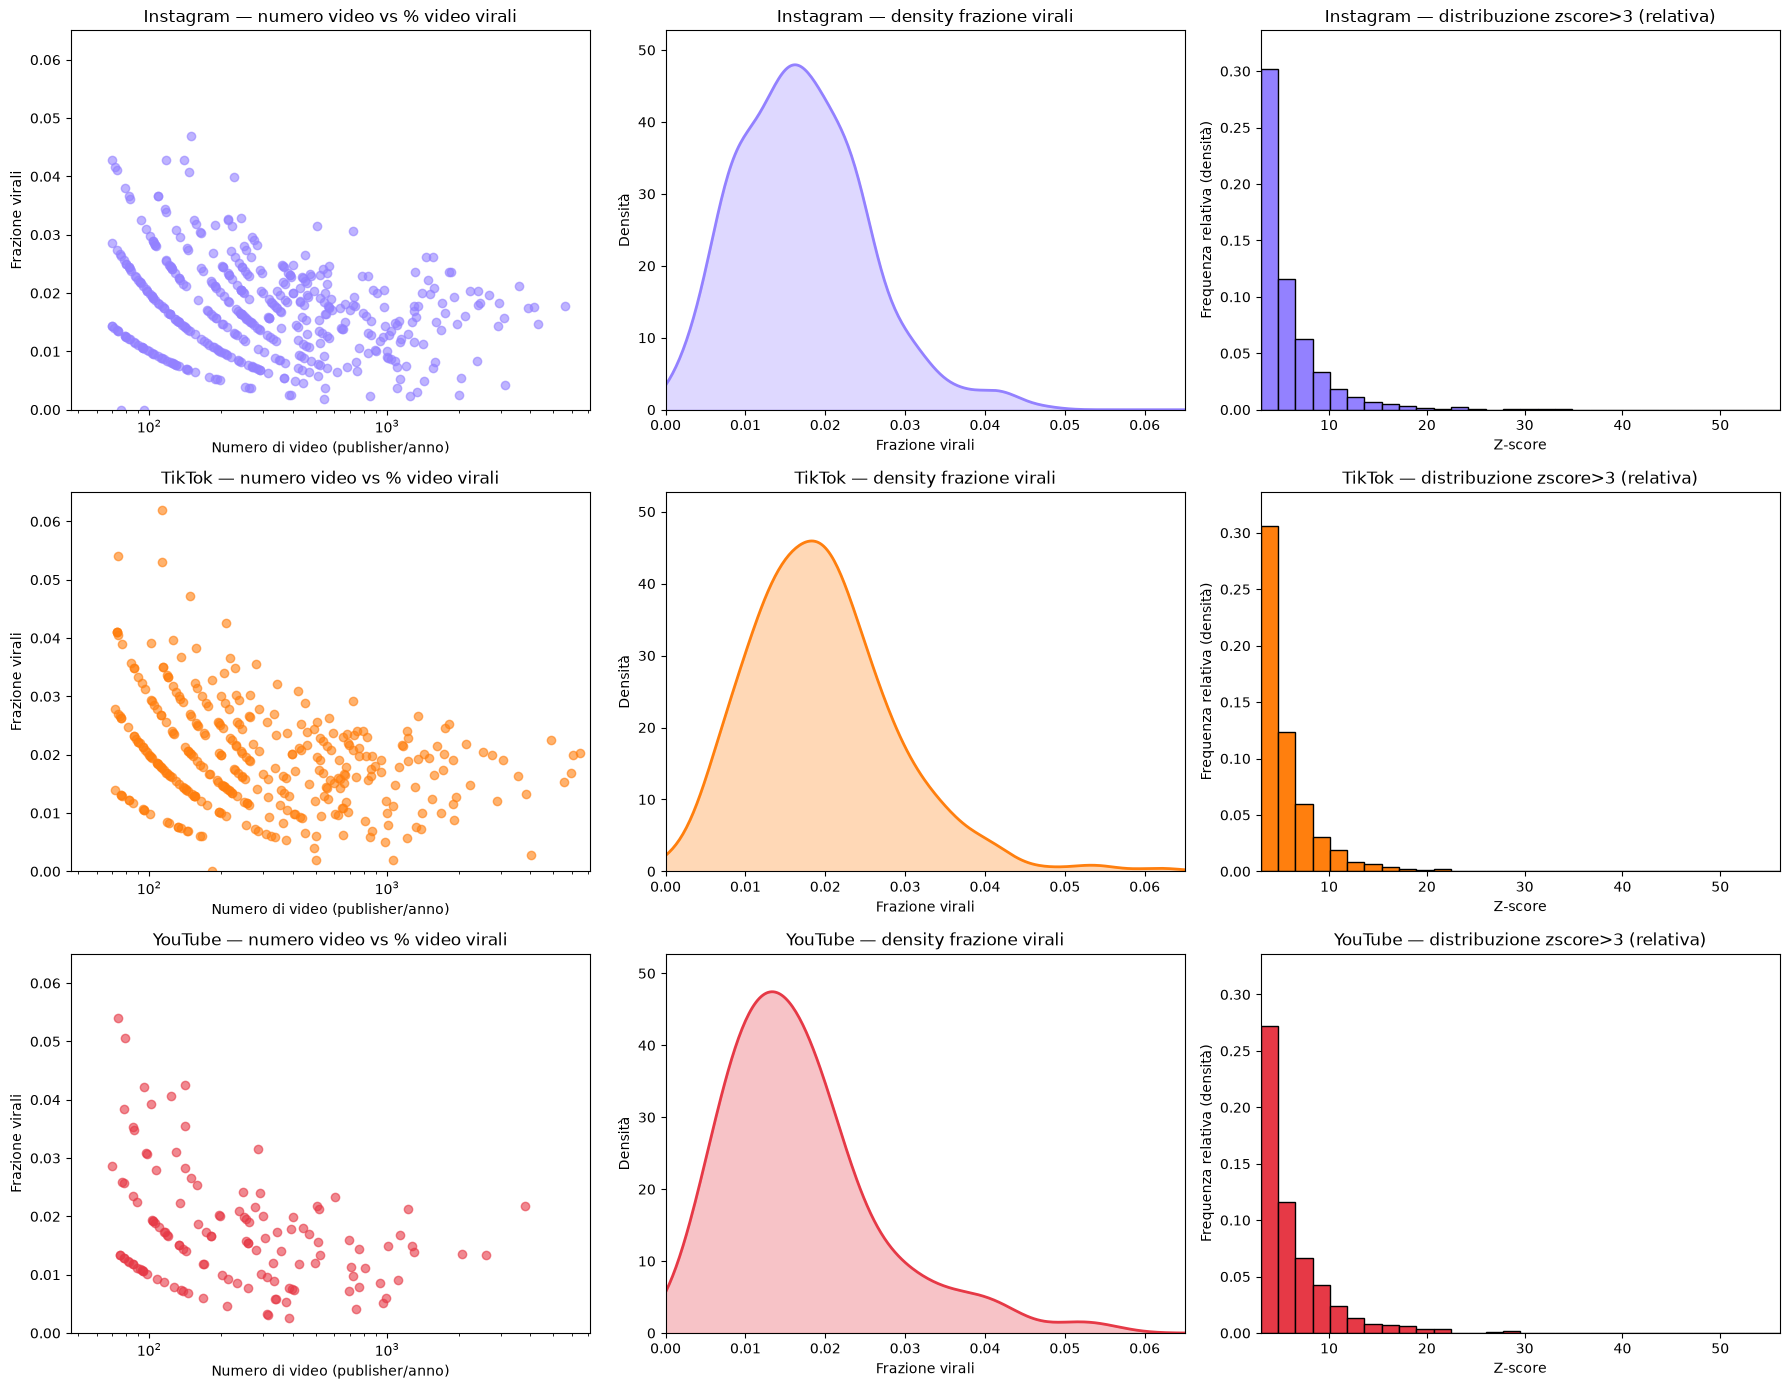

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ---------------------------------------------------------
# 0. Dataset e palette per piattaforma
# ---------------------------------------------------------
tiktok    = tiktok_active[['video_id', 'publisher', 'year', 'views', 'platform']].copy()
youtube   = youtube_active[['video_id', 'publisher', 'year', 'views', 'platform']].copy()
instagram = instagram_active[['video_id', 'publisher', 'year', 'views', 'platform']].copy()

datasets = {
    "Instagram": instagram,
    "TikTok": tiktok,
    "YouTube": youtube,
}

palette = {
    "Instagram": "#9381FF",
    "TikTok": "#ff7f0e",
    "YouTube": "#e63946",
}

col = 'views'


def zscore(x):
    return (x - x.mean()) / x.std(ddof=0)


# ---------------------------------------------------------
# 1. Calcolo zscore, outlier (>3), summary per publisher/anno
# ---------------------------------------------------------
summaries = {}

for name, df in datasets.items():
    df['zscore'] = df.groupby(['publisher', 'year'])[col].transform(zscore)
    df['is_viral'] = df['zscore'] > 3

    summary = (
        df.groupby(['publisher', 'year'])
        .agg(
            totale=('is_viral', 'size'),
            n_virali=('is_viral', 'sum')
        )
        .reset_index()
    )
    summary['frazione_virali'] = summary['n_virali'] / summary['totale']
    summaries[name] = summary

    print(f"\n=== {name.upper()} — numero e frazione di video virali (zscore>3) per publisher/anno ===")
    print(summary.sort_values('frazione_virali', ascending=False).to_string(index=False))

# ---------------------------------------------------------
# 2. Limiti condivisi tra le 3 piattaforme
# ---------------------------------------------------------

# Frazione virali: range comune per colonna 1 (scatter) e colonna 2 (density)
all_frazioni = pd.concat([s['frazione_virali'] for s in summaries.values()])
frac_min, frac_max = 0, all_frazioni.max() * 1.05

# Totale video: range comune per colonna 1 (scatter, asse x) — ora in scala log
all_totali = pd.concat([s['totale'] for s in summaries.values()])
tot_min, tot_max = all_totali.min(), all_totali.max()

# Zscore > 3: range comune per colonna 3 (istogramma)
all_virali_z = pd.concat([df.loc[df['is_viral'], 'zscore'] for df in datasets.values()])
z_min, z_max = all_virali_z.min(), all_virali_z.max()

# istogramma con asse y relativo (density=True) -> calcolo il max comune di densità
max_hist_density = 0
for df in datasets.values():
    counts, _ = np.histogram(df.loc[df['is_viral'], 'zscore'], bins=30, range=(z_min, z_max), density=True)
    max_hist_density = max(max_hist_density, counts.max())

# Density (colonna 2): calcolo KDE per ciascuna piattaforma e trovo il massimo comune di densità
x_grid = np.linspace(frac_min, frac_max, 300)
kdes = {}
max_density = 0
for name, summary in summaries.items():
    values = summary['frazione_virali'].values
    if len(np.unique(values)) > 1:
        kde = gaussian_kde(values)
        density = kde(x_grid)
    else:
        density = np.zeros_like(x_grid)
    kdes[name] = density
    max_density = max(max_density, density.max())

# ---------------------------------------------------------
# 3. Griglia di plot: 3 righe (piattaforme) x 3 colonne
#    Col 1: scatter numero video (totale, log scale) vs percentuale video virali
#    Col 2: density della frazione virali
#    Col 3: distribuzione zscore > 3, asse y relativo (densità)
# ---------------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

for i, (name, df) in enumerate(datasets.items()):
    summary = summaries[name]
    color = palette[name]
    virali_z = df.loc[df['is_viral'], 'zscore']

    # Col 1: scatter totale video (log) vs frazione virali
    ax = axes[i, 0]
    ax.scatter(summary['totale'], summary['frazione_virali'], alpha=0.6, color=color)
    ax.set_title(f'{name} — numero video vs % video virali')
    ax.set_xlabel('Numero di video (publisher/anno)')
    ax.set_ylabel('Frazione virali')
    ax.set_xscale('log')
    ax.set_xlim(tot_min / 1.5, tot_max * 1.1)
    ax.set_ylim(frac_min, frac_max)

    # Col 2: density della frazione virali
    ax = axes[i, 1]
    ax.plot(x_grid, kdes[name], color=color, linewidth=2)
    ax.fill_between(x_grid, kdes[name], color=color, alpha=0.3)
    ax.set_title(f'{name} — density frazione virali')
    ax.set_xlabel('Frazione virali')
    ax.set_ylabel('Densità')
    ax.set_xlim(frac_min, frac_max)
    ax.set_ylim(0, max_density * 1.1)

    # Col 3: distribuzione zscore > 3, asse y relativo (density=True)
    ax = axes[i, 2]
    ax.hist(virali_z, bins=30, range=(z_min, z_max), density=True, color=color, edgecolor='black')
    ax.set_title(f'{name} — distribuzione zscore>3 (relativa)')
    ax.set_xlabel('Z-score')
    ax.set_ylabel('Frequenza relativa (densità)')
    ax.set_xlim(z_min, z_max)
    ax.set_ylim(0, max_hist_density * 1.1)

plt.tight_layout()
plt.show()

Mediana

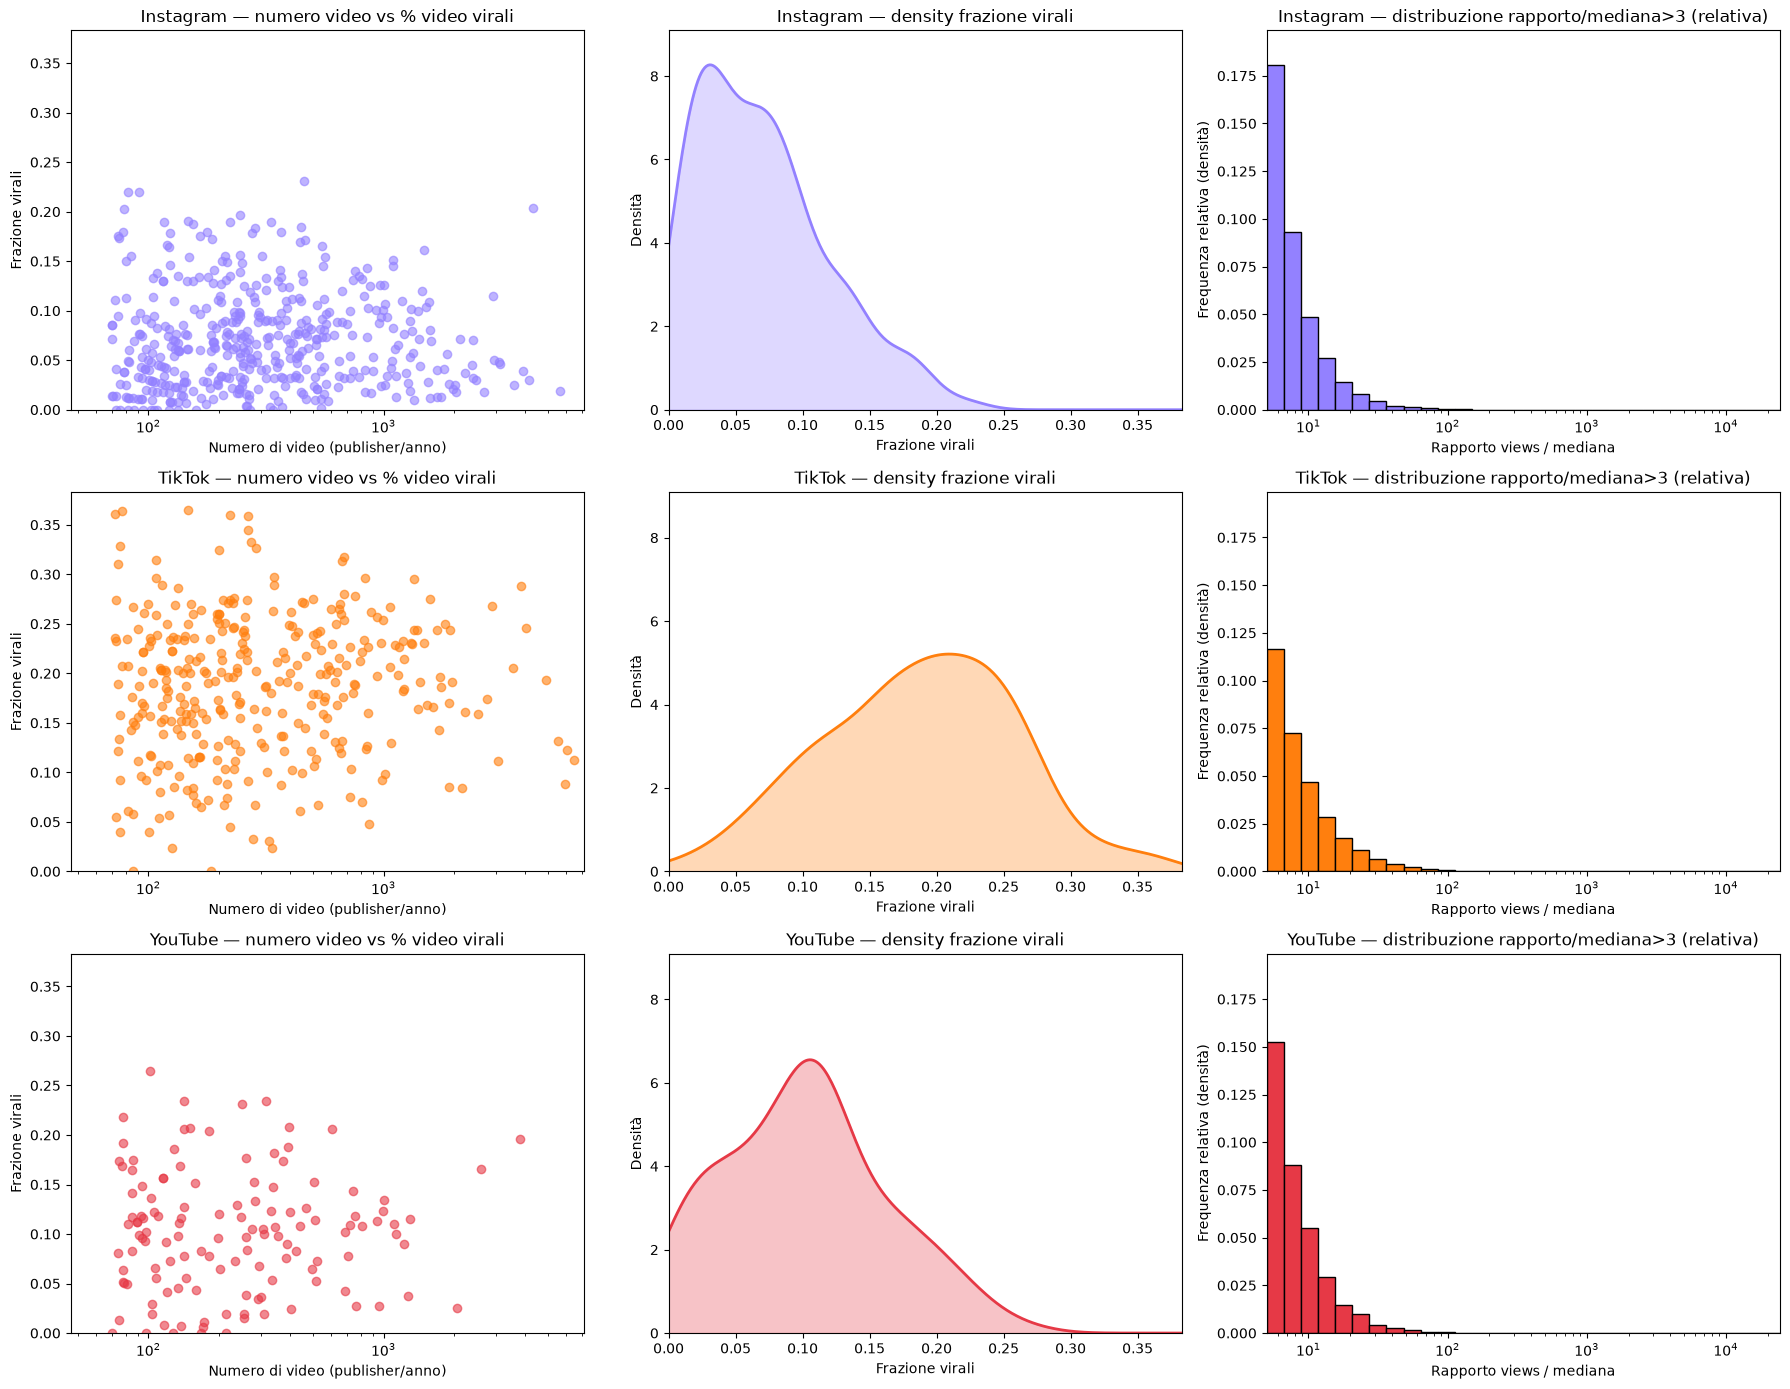

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ---------------------------------------------------------
# 0. Dataset e palette per piattaforma
# ---------------------------------------------------------
tiktok    = tiktok_active[['video_id', 'publisher', 'year', 'views', 'platform']].copy()
youtube   = youtube_active[['video_id', 'publisher', 'year', 'views', 'platform']].copy()
instagram = instagram_active[['video_id', 'publisher', 'year', 'views', 'platform']].copy()

datasets = {
    "Instagram": instagram,
    "TikTok": tiktok,
    "YouTube": youtube,
}

palette = {
    "Instagram": "#9381FF",
    "TikTok": "#ff7f0e",
    "YouTube": "#e63946",
}

col = 'views'


def rapporto_mediana(x):
    return x / x.median()


# ---------------------------------------------------------
# 1. Calcolo rapporto alla mediana, outlier (>3), summary per publisher/anno
# ---------------------------------------------------------
summaries = {}

for name, df in datasets.items():
    df['zscore'] = df.groupby(['publisher', 'year'])[col].transform(rapporto_mediana)
    df['is_viral'] = df['zscore'] > 5

    summary = (
        df.groupby(['publisher', 'year'])
        .agg(
            totale=('is_viral', 'size'),
            n_virali=('is_viral', 'sum')
        )
        .reset_index()
    )
    summary['frazione_virali'] = summary['n_virali'] / summary['totale']
    summaries[name] = summary

# ---------------------------------------------------------
# 2. Limiti condivisi tra le 3 piattaforme
# ---------------------------------------------------------

# Frazione virali: range comune per colonna 1 (scatter) e colonna 2 (density)
all_frazioni = pd.concat([s['frazione_virali'] for s in summaries.values()])
frac_min, frac_max = 0, all_frazioni.max() * 1.05

# Totale video: range comune per colonna 1 (scatter, asse x) — scala log
all_totali = pd.concat([s['totale'] for s in summaries.values()])
tot_min, tot_max = all_totali.min(), all_totali.max()

# Rapporto mediana > 3: range comune per colonna 3 (istogramma, scala log)
all_virali_z = pd.concat([df.loc[df['is_viral'], 'zscore'] for df in datasets.values()])
z_min, z_max = all_virali_z.min(), all_virali_z.max()

# istogramma con bin log-spaced (più corretto in scala log) e asse y relativo (density=True)
log_bins = np.logspace(np.log10(z_min), np.log10(z_max), 31)
max_hist_density = 0
for df in datasets.values():
    counts, _ = np.histogram(df.loc[df['is_viral'], 'zscore'], bins=log_bins, density=True)
    max_hist_density = max(max_hist_density, counts.max())

# Density (colonna 2): calcolo KDE per ciascuna piattaforma e trovo il massimo comune di densità
x_grid = np.linspace(frac_min, frac_max, 300)
kdes = {}
max_density = 0
for name, summary in summaries.items():
    values = summary['frazione_virali'].values
    if len(np.unique(values)) > 1:
        kde = gaussian_kde(values)
        density = kde(x_grid)
    else:
        density = np.zeros_like(x_grid)
    kdes[name] = density
    max_density = max(max_density, density.max())

# ---------------------------------------------------------
# 3. Griglia di plot: 3 righe (piattaforme) x 3 colonne
#    Col 1: scatter numero video (totale, log scale) vs percentuale video virali
#    Col 2: density della frazione virali
#    Col 3: distribuzione rapporto mediana > 3, asse x log, asse y relativo (densità)
# ---------------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

for i, (name, df) in enumerate(datasets.items()):
    summary = summaries[name]
    color = palette[name]
    virali_z = df.loc[df['is_viral'], 'zscore']

    # Col 1: scatter totale video (log) vs frazione virali
    ax = axes[i, 0]
    ax.scatter(summary['totale'], summary['frazione_virali'], alpha=0.6, color=color)
    ax.set_title(f'{name} — numero video vs % video virali')
    ax.set_xlabel('Numero di video (publisher/anno)')
    ax.set_ylabel('Frazione virali')
    ax.set_xscale('log')
    ax.set_xlim(tot_min / 1.5, tot_max * 1.1)
    ax.set_ylim(frac_min, frac_max)

    # Col 2: density della frazione virali
    ax = axes[i, 1]
    ax.plot(x_grid, kdes[name], color=color, linewidth=2)
    ax.fill_between(x_grid, kdes[name], color=color, alpha=0.3)
    ax.set_title(f'{name} — density frazione virali')
    ax.set_xlabel('Frazione virali')
    ax.set_ylabel('Densità')
    ax.set_xlim(frac_min, frac_max)
    ax.set_ylim(0, max_density * 1.1)

    # Col 3: distribuzione rapporto mediana > 3, asse x log, asse y relativo (density=True)
    ax = axes[i, 2]
    ax.hist(virali_z, bins=log_bins, density=True, color=color, edgecolor='black')
    ax.set_title(f'{name} — distribuzione rapporto/mediana>3 (relativa)')
    ax.set_xlabel('Rapporto views / mediana')
    ax.set_ylabel('Frequenza relativa (densità)')
    ax.set_xscale('log')
    ax.set_xlim(z_min, z_max)
    ax.set_ylim(0, max_hist_density * 1.1)

plt.tight_layout()
plt.show()

Bootstrap con lo zeta score


=== INSTAGRAM — bootstrap (30 video x 100 iter) — frazione virali media per publisher/anno ===
                     publisher  year  totale  frazione_virali  frazione_virali_std
                   Radio Radio  2023      70         0.040667             0.016720
             Euronews italiano  2025     275         0.040000             0.014907
               Fondazione AIRC  2025      87         0.040000             0.020548
                          Oggi  2026     256         0.039667             0.016121
                Milano Finanza  2025     107         0.039667             0.020382
                      Genova24  2026     116         0.039000             0.014948
                       Dire.it  2026     459         0.039000             0.012521
                    GAY.IT 🌍🪐✨  2024      83         0.039000             0.017673
         Il Piccolo di Trieste  2026     147         0.039000             0.018291
                   Radio Radio  2026     451         0.038667             

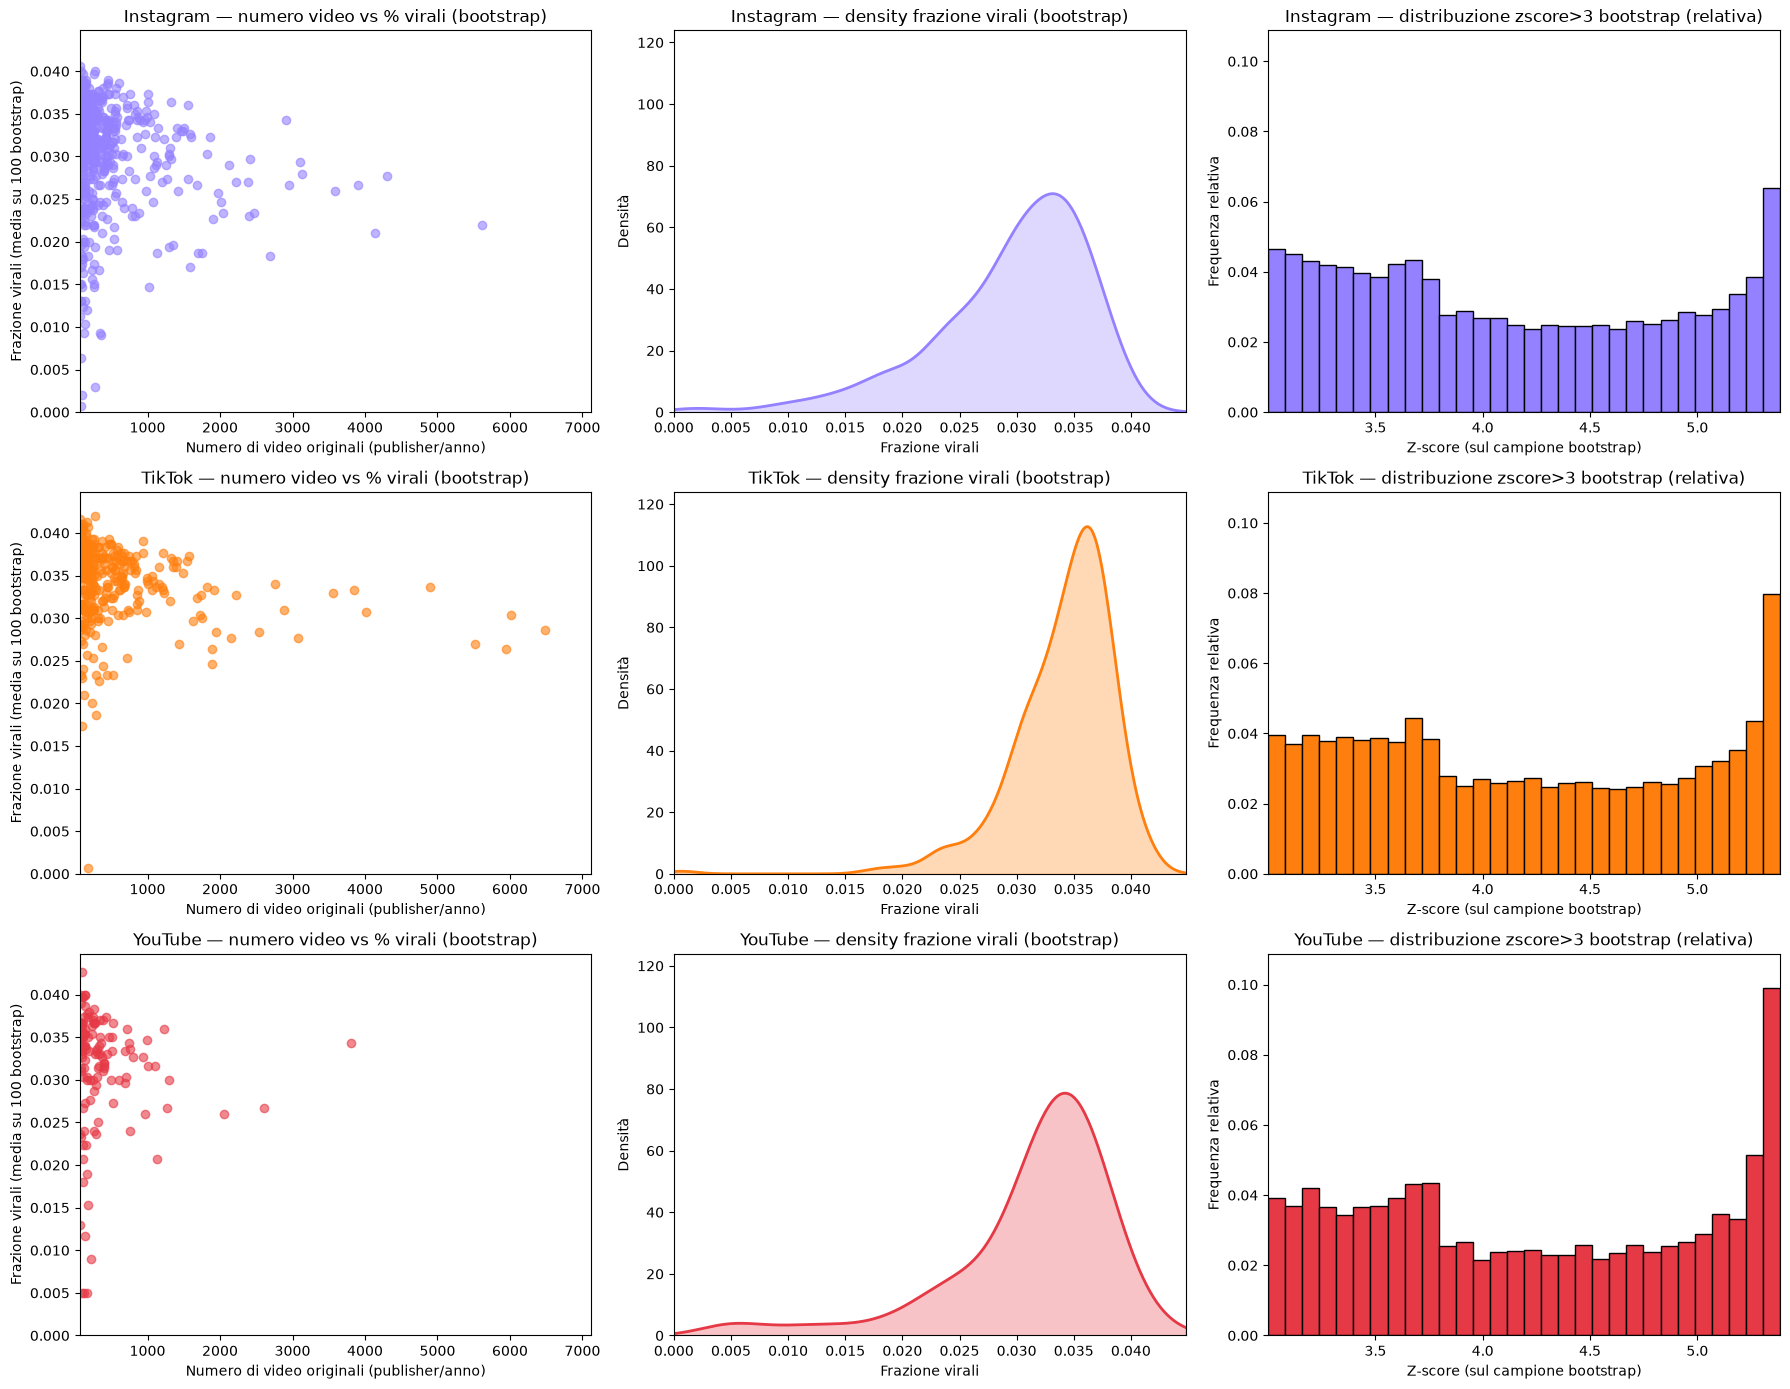

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

np.random.seed(42)  # riproducibilità

# ---------------------------------------------------------
# 0. Dataset e palette per piattaforma
# ---------------------------------------------------------
tiktok    = tiktok_active[['video_id', 'publisher', 'year', 'views', 'platform']].copy()
youtube   = youtube_active[['video_id', 'publisher', 'year', 'views', 'platform']].copy()
instagram = instagram_active[['video_id', 'publisher', 'year', 'views', 'platform']].copy()

datasets = {
    "Instagram": instagram,
    "TikTok": tiktok,
    "YouTube": youtube,
}

palette = {
    "Instagram": "#9381FF",
    "TikTok": "#ff7f0e",
    "YouTube": "#e63946",
}

col = 'views'
N_BOOTSTRAP = 100
SAMPLE_SIZE = 30


def zscore(x):
    return (x - x.mean()) / x.std(ddof=0)


# ---------------------------------------------------------
# 1. Bootstrap: per ogni coppia publisher/anno, campiono 30 video
#    (con reinserimento) 100 volte, calcolo lo zscore SUL CAMPIONE
#    e la frazione di virali (zscore>3) in ciascun campione.
#    La frazione finale è la media sulle 100 iterazioni.
# ---------------------------------------------------------
summaries = {}
bootstrap_virali_z = {}  # tutti gli zscore>3 osservati nei campioni bootstrap, per il plot di distribuzione

for name, df in datasets.items():
    records = []
    zscore_virali_list = []

    for (publisher, year), group in df.groupby(['publisher', 'year']):
        totale_originale = len(group)
        frazioni_bootstrap = []

        for _ in range(N_BOOTSTRAP):
            sample = group.sample(n=SAMPLE_SIZE, replace=True)
            sample_z = zscore(sample[col])
            is_viral_sample = sample_z > 3
            frazioni_bootstrap.append(is_viral_sample.mean())
            zscore_virali_list.extend(sample_z[is_viral_sample].tolist())

        records.append({
            'publisher': publisher,
            'year': year,
            'totale': totale_originale,          # numero di video originali nel gruppo
            'frazione_virali': np.mean(frazioni_bootstrap),   # media su 100 bootstrap
            'frazione_virali_std': np.std(frazioni_bootstrap)  # variabilità tra bootstrap
        })

    summary = pd.DataFrame(records)
    summaries[name] = summary
    bootstrap_virali_z[name] = np.array(zscore_virali_list)

    print(f"\n=== {name.upper()} — bootstrap ({SAMPLE_SIZE} video x {N_BOOTSTRAP} iter) "
          f"— frazione virali media per publisher/anno ===")
    print(summary.sort_values('frazione_virali', ascending=False).to_string(index=False))

# ---------------------------------------------------------
# 2. Limiti condivisi tra le 3 piattaforme
# ---------------------------------------------------------

# Frazione virali: range comune per colonna 1 (scatter) e colonna 2 (density)
all_frazioni = pd.concat([s['frazione_virali'] for s in summaries.values()])
frac_min, frac_max = 0, all_frazioni.max() * 1.05

# Totale video (originali): range comune per colonna 1 (scatter, asse x)
all_totali = pd.concat([s['totale'] for s in summaries.values()])
tot_min, tot_max = all_totali.min(), all_totali.max()

# Zscore > 3 osservati nei campioni bootstrap: range comune per colonna 3 (istogramma)
all_virali_z = np.concatenate(list(bootstrap_virali_z.values()))
z_min, z_max = all_virali_z.min(), all_virali_z.max()

# istogramma con vera frequenza relativa (weights, non density) -> calcolo il max comune
max_hist_freq = 0
for name in datasets:
    virali_z = bootstrap_virali_z[name]
    weights = np.ones_like(virali_z) / len(virali_z)
    counts, _ = np.histogram(virali_z, bins=30, range=(z_min, z_max), weights=weights)
    max_hist_freq = max(max_hist_freq, counts.max())

# Density (colonna 2): calcolo KDE per ciascuna piattaforma e trovo il massimo comune di densità
x_grid = np.linspace(frac_min, frac_max, 300)
kdes = {}
max_density = 0
for name, summary in summaries.items():
    values = summary['frazione_virali'].values
    if len(np.unique(values)) > 1:
        kde = gaussian_kde(values)
        density = kde(x_grid)
    else:
        density = np.zeros_like(x_grid)
    kdes[name] = density
    max_density = max(max_density, density.max())

# ---------------------------------------------------------
# 3. Griglia di plot: 3 righe (piattaforme) x 3 colonne
#    Col 1: scatter numero video (totale originale) vs frazione virali (media bootstrap)
#    Col 2: density della frazione virali (media bootstrap)
#    Col 3: distribuzione zscore > 3 (da tutti i campioni bootstrap), vera frequenza relativa
# ---------------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

for i, name in enumerate(datasets):
    summary = summaries[name]
    color = palette[name]
    virali_z = bootstrap_virali_z[name]

    # Col 1: scatter totale video (originale) vs frazione virali media (bootstrap)
    ax = axes[i, 0]
    ax.scatter(summary['totale'], summary['frazione_virali'], alpha=0.6, color=color)
    ax.set_title(f'{name} — numero video vs % virali (bootstrap)')
    ax.set_xlabel('Numero di video originali (publisher/anno)')
    ax.set_ylabel('Frazione virali (media su 100 bootstrap)')
    ax.set_xlim(tot_min * 0.9, tot_max * 1.1)
    ax.set_ylim(frac_min, frac_max)

    # Col 2: density della frazione virali (media bootstrap)
    ax = axes[i, 1]
    ax.plot(x_grid, kdes[name], color=color, linewidth=2)
    ax.fill_between(x_grid, kdes[name], color=color, alpha=0.3)
    ax.set_title(f'{name} — density frazione virali (bootstrap)')
    ax.set_xlabel('Frazione virali')
    ax.set_ylabel('Densità')
    ax.set_xlim(frac_min, frac_max)
    ax.set_ylim(0, max_density * 1.1)

    # Col 3: distribuzione zscore > 3 sui campioni bootstrap, vera frequenza relativa (≤ 1)
    ax = axes[i, 2]
    weights = np.ones_like(virali_z) / len(virali_z)
    ax.hist(virali_z, bins=30, range=(z_min, z_max), weights=weights,
            color=color, edgecolor='black')
    ax.set_title(f'{name} — distribuzione zscore>3 bootstrap (relativa)')
    ax.set_xlabel('Z-score (sul campione bootstrap)')
    ax.set_ylabel('Frequenza relativa')
    ax.set_xlim(z_min, z_max)
    ax.set_ylim(0, max_hist_freq * 1.1)

plt.tight_layout()
plt.show()

Bootstrap con la mediana 


=== INSTAGRAM — bootstrap (100 video x 100 iter) — frazione virali media per publisher/anno (soglia rapporto/mediana > 10) ===
                     publisher  year  totale  frazione_virali  frazione_virali_std
                     Adnkronos  2026      82           0.1799             0.034626
               DiLei Take Care  2025      91           0.1553             0.031826
                       Dire.it  2026     459           0.1508             0.031295
                    QuiFinanza  2025     133           0.1410             0.032357
         Il Piccolo di Trieste  2026     147           0.1345             0.031476
                    Notizie.it  2024     165           0.1306             0.028977
                      Canale10  2025     155           0.1262             0.029657
                    StrettoWeb  2025      84           0.1192             0.036734
             Euronews italiano  2025     275           0.1185             0.032043
                      meteo.it  2024     1

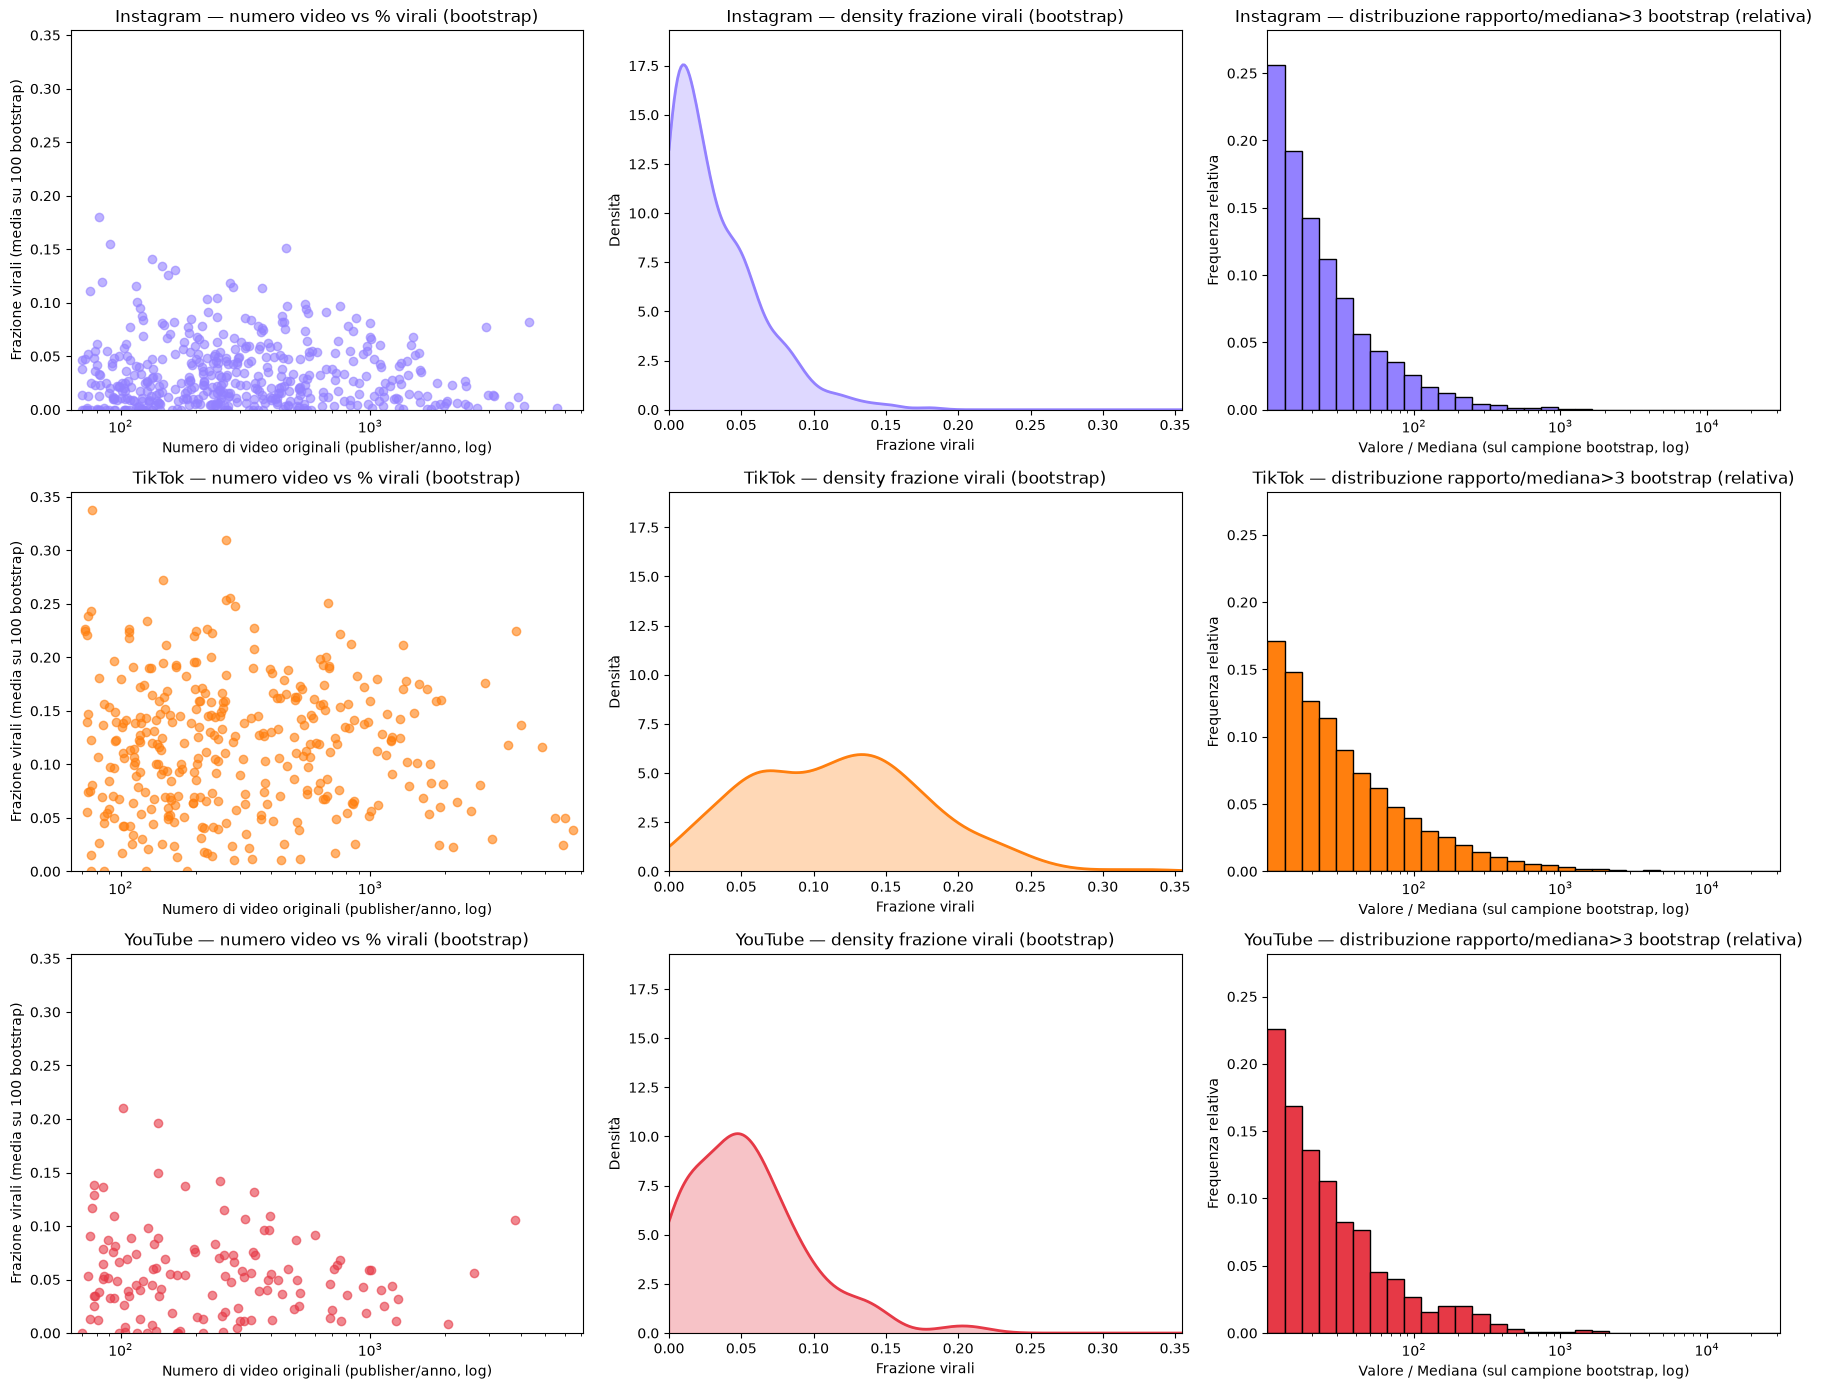

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

np.random.seed(42)  # riproducibilità

# ---------------------------------------------------------
# 0. Dataset e palette per piattaforma
# ---------------------------------------------------------
tiktok    = tiktok_active[['video_id', 'publisher', 'year', 'views', 'platform']].copy()
youtube   = youtube_active[['video_id', 'publisher', 'year', 'views', 'platform']].copy()
instagram = instagram_active[['video_id', 'publisher', 'year', 'views', 'platform']].copy()

datasets = {
    "Instagram": instagram,
    "TikTok": tiktok,
    "YouTube": youtube,
}

palette = {
    "Instagram": "#9381FF",
    "TikTok": "#ff7f0e",
    "YouTube": "#e63946",
}

col = 'views'
N_BOOTSTRAP = 100
SAMPLE_SIZE = 100
SOGLIA = 10


def rapporto_mediana(x):
    """Valore diviso la mediana del campione (al posto dello zscore).
    Se la mediana è 0, il rapporto non è definito -> restituisco NaN
    per quei valori invece di andare in inf."""
    median = x.median()
    if median == 0:
        return pd.Series(np.nan, index=x.index)
    return x / median


# ---------------------------------------------------------
# 1. Bootstrap: per ogni coppia publisher/anno, campiono 30 video
#    (con reinserimento) 100 volte, calcolo il rapporto valore/mediana
#    SUL CAMPIONE e la frazione di virali (rapporto > 3) in ciascun campione.
#    La frazione finale è la media sulle 100 iterazioni.
# ---------------------------------------------------------
summaries = {}
bootstrap_virali_ratio = {}  # tutti i rapporti > 3 osservati nei campioni bootstrap, per il plot di distribuzione

for name, df in datasets.items():
    records = []
    ratio_virali_list = []

    for (publisher, year), group in df.groupby(['publisher', 'year']):
        totale_originale = len(group)
        frazioni_bootstrap = []

        for _ in range(N_BOOTSTRAP):
            sample = group.sample(n=SAMPLE_SIZE, replace=True)
            sample_ratio = rapporto_mediana(sample[col])
            is_viral_sample = sample_ratio > SOGLIA  # NaN > 3 è False, quindi non conta come virale
            frazioni_bootstrap.append(is_viral_sample.mean())
            valid_virali = sample_ratio[is_viral_sample]
            valid_virali = valid_virali[np.isfinite(valid_virali)]  # scarta eventuali inf/nan residui
            ratio_virali_list.extend(valid_virali.tolist())

        records.append({
            'publisher': publisher,
            'year': year,
            'totale': totale_originale,          # numero di video originali nel gruppo
            'frazione_virali': np.mean(frazioni_bootstrap),   # media su 100 bootstrap
            'frazione_virali_std': np.std(frazioni_bootstrap)  # variabilità tra bootstrap
        })

    summary = pd.DataFrame(records)
    summaries[name] = summary
    bootstrap_virali_ratio[name] = np.array(ratio_virali_list)

    print(f"\n=== {name.upper()} — bootstrap ({SAMPLE_SIZE} video x {N_BOOTSTRAP} iter) "
          f"— frazione virali media per publisher/anno (soglia rapporto/mediana > {SOGLIA}) ===")
    print(summary.sort_values('frazione_virali', ascending=False).to_string(index=False))

# ---------------------------------------------------------
# 2. Limiti condivisi tra le 3 piattaforme
# ---------------------------------------------------------

# Frazione virali: range comune per colonna 1 (scatter) e colonna 2 (density)
all_frazioni = pd.concat([s['frazione_virali'] for s in summaries.values()])
frac_min, frac_max = 0, all_frazioni.max() * 1.05

# Totale video (originali): range comune per colonna 1 (scatter, asse x in log)
all_totali = pd.concat([s['totale'] for s in summaries.values()])
tot_min, tot_max = all_totali.min(), all_totali.max()

# Rapporto/mediana > 3 osservati nei campioni bootstrap: range comune per colonna 3 (istogramma, asse x in log)
all_virali_ratio = np.concatenate(list(bootstrap_virali_ratio.values()))
all_virali_ratio = all_virali_ratio[np.isfinite(all_virali_ratio)]  # sicurezza extra
r_min, r_max = all_virali_ratio.min(), all_virali_ratio.max()

# per la scala log, i bin devono essere logaritmicamente spaziati e r_min deve essere > 0
# (è già garantito: SOGLIA = 3, quindi tutti i valori sono > 3)
log_bins = np.logspace(np.log10(r_min), np.log10(r_max), 31)

# istogramma con vera frequenza relativa (weights, non density) -> calcolo il max comune
max_hist_freq = 0
for name in datasets:
    virali_ratio = bootstrap_virali_ratio[name]
    virali_ratio = virali_ratio[np.isfinite(virali_ratio)]  # scarta eventuali inf/nan
    if len(virali_ratio) == 0:
        continue
    weights = np.ones_like(virali_ratio) / len(virali_ratio)
    counts, _ = np.histogram(virali_ratio, bins=log_bins, weights=weights)
    max_hist_freq = max(max_hist_freq, counts.max())

# Density (colonna 2): calcolo KDE per ciascuna piattaforma e trovo il massimo comune di densità
x_grid = np.linspace(frac_min, frac_max, 300)
kdes = {}
max_density = 0
for name, summary in summaries.items():
    values = summary['frazione_virali'].values
    if len(np.unique(values)) > 1:
        kde = gaussian_kde(values)
        density = kde(x_grid)
    else:
        density = np.zeros_like(x_grid)
    kdes[name] = density
    max_density = max(max_density, density.max())

# ---------------------------------------------------------
# 3. Griglia di plot: 3 righe (piattaforme) x 3 colonne
#    Col 1: scatter numero video (totale originale, asse x log) vs frazione virali (media bootstrap)
#    Col 2: density della frazione virali (media bootstrap)
#    Col 3: distribuzione rapporto/mediana > 3 (asse x log), vera frequenza relativa
# ---------------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

for i, name in enumerate(datasets):
    summary = summaries[name]
    color = palette[name]
    virali_ratio = bootstrap_virali_ratio[name]youtube
    virali_ratio = virali_ratio[np.isfinite(virali_ratio)]  # scarta eventuali inf/nan prima del plot

    # Col 1: scatter totale video (originale, asse x log) vs frazione virali media (bootstrap)
    ax = axes[i, 0]
    ax.scatter(summary['totale'], summary['frazione_virali'], alpha=0.6, color=color)
    ax.set_title(f'{name} — numero video vs % virali (bootstrap)')
    ax.set_xlabel('Numero di video originali (publisher/anno, log)')
    ax.set_ylabel('Frazione virali (media su 100 bootstrap)')
    ax.set_xscale('log')
    ax.set_xlim(tot_min * 0.9, tot_max * 1.1)
    ax.set_ylim(frac_min, frac_max)

    # Col 2: density della frazione virali (media bootstrap)
    ax = axes[i, 1]
    ax.plot(x_grid, kdes[name], color=color, linewidth=2)
    ax.fill_between(x_grid, kdes[name], color=color, alpha=0.3)
    ax.set_title(f'{name} — density frazione virali (bootstrap)')
    ax.set_xlabel('Frazione virali')
    ax.set_ylabel('Densità')
    ax.set_xlim(frac_min, frac_max)
    ax.set_ylim(0, max_density * 1.1)

    # Col 3: distribuzione rapporto/mediana > 3 sui campioni bootstrap (asse x log), vera frequenza relativa (≤ 1)
    ax = axes[i, 2]
    if len(virali_ratio) > 0:
        weights = np.ones_like(virali_ratio) / len(virali_ratio)
        ax.hist(virali_ratio, bins=log_bins, weights=weights,
                color=color, edgecolor='black')
    ax.set_title(f'{name} — distribuzione rapporto/mediana>3 bootstrap (relativa)')
    ax.set_xlabel('Valore / Mediana (sul campione bootstrap, log)')
    ax.set_ylabel('Frequenza relativa')
    ax.set_xscale('log')
    ax.set_xlim(r_min, r_max)
    ax.set_ylim(0, max_hist_freq * 1.1)

plt.tight_layout()
plt.show()